# Data层功能验证：真实市场数据

本 notebook 的研究目的不是做策略回测，而是系统验证 `cta_lab/data` 在真实 `market_data` 上的可用性、接口一致性和研究友好性。

本次验证覆盖：
- 国内日线 K 线加载与指标计算
- Contract / Calendar / Instrument 三类静态数据访问
- ContinuousSeries 的价格链与标准化净值链
- 海外数据格式适配
- schedule 恢复与连续合约构建行为


## 1. 环境与加载器配置

这一节构造两套 `DataLoader`：
- `china_loader`：国内期货日线 + 合约 + 日历 + 第一版 instrument 主数据
- `overseas_loader`：海外期货日线 + 合约 + 第一版 instrument 主数据


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT_DIR = Path("/home/ubuntu/dengl/my_projects/cta_lab")
MARKET_DATA = ROOT_DIR.parent / "market_data"
sys.path.insert(0, str(ROOT_DIR))

plt.style.use("default")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)


In [2]:
from data.loader import DataLoader, KlineSchema, ContractSchema, InstrumentSchema
from data.sources import ParquetSource, ColumnKeyedSource


In [3]:
china_loader = DataLoader(
    kline_source=ParquetSource(MARKET_DATA / "kline" / "china_daily_full"),
    contract_source=ColumnKeyedSource(
        MARKET_DATA / "contracts" / "china" / "contract_info.parquet",
        filter_col="fut_code",
    ),
    calendar_source=ColumnKeyedSource(
        MARKET_DATA / "calendar" / "china_trading_calendar.parquet",
        filter_col="exchange",
    ),
    instrument_source=ColumnKeyedSource(
        MARKET_DATA / "contracts" / "china" / "contract_info.parquet",
        filter_col="fut_code",
    ),
    kline_schema=KlineSchema.tushare(),
    contract_schema=ContractSchema.tushare(),
    instrument_schema=InstrumentSchema.china_from_contracts(),
)

overseas_loader = DataLoader(
    kline_source=ParquetSource(MARKET_DATA / "kline" / "overseas_daily_full"),
    contract_source=ColumnKeyedSource(
        MARKET_DATA / "contracts" / "overseas" / "contract_info.parquet",
        filter_col="BaseTicker",
    ),
    instrument_source=ColumnKeyedSource(
        MARKET_DATA / "contracts" / "overseas" / "contract_info.parquet",
        filter_col="BaseTicker",
    ),
    kline_schema=KlineSchema.overseas(),
    contract_schema=ContractSchema.overseas(),
    instrument_schema=InstrumentSchema.overseas_from_contracts(),
)


## 2. 国内数据：BarSeries 与固有分析方法

先验证 `load_bar_series()` 是否能基于真实 `china_daily_full` 文件正确解析单合约行情。


In [4]:
rb = china_loader.load_bar_series("RB2410.SHF")
rb


BarSeries(symbol='RB2410.SHF', rows=241, range=[2023-10-17 ~ 2024-10-15])

In [5]:
rb.data.head()


,open,high,low,close,settle,volume,open_interest
date,,,,,,,
2023-10-17,3600.0,3650.0,3600.0,3631.0,3631.0,1140.0,893.0
2023-10-18,3636.0,3636.0,3593.0,3602.0,3615.0,1050.0,1642.0
2023-10-19,3612.0,3633.0,3590.0,3623.0,3608.0,818.0,2070.0
2023-10-20,3630.0,3638.0,3580.0,3588.0,3606.0,1554.0,3088.0
2023-10-23,3580.0,3595.0,3555.0,3568.0,3570.0,2058.0,4175.0


In [6]:
pd.DataFrame({
    "settle": rb.data["settle"].head(),
    "log_ret": rb.log_returns().head(),
    "ewm_vol_60": rb.ewm_vol(60).head(),
    "drawdown": rb.drawdown().head(),
})


,settle,log_ret,ewm_vol_60,drawdown
date,,,,
2023-10-17,3631.0,NaN,NaN,0.000000
2023-10-18,3615.0,-0.004416,NaN,-0.004406
2023-10-19,3608.0,-0.001938,0.027815,-0.006334
2023-10-20,3606.0,-0.000554,0.031026,-0.006885
2023-10-23,3570.0,-0.010034,0.066792,-0.016800


## 3. 国内静态数据：Contract / Calendar / Instrument

这一节检查 `data` 层是否已经能把合约主表、交易日历和第一版 instrument 主数据稳定地组织成领域对象。


In [7]:
contracts_rb = china_loader.load_contracts("RB")
len(contracts_rb), contracts_rb[:3]


(211,
 [Contract(symbol='RB', code='RB0909.SHF', exchange='SHFE', list_date=datetime.date(2009, 3, 27), expire_date=datetime.date(2009, 9, 15), last_trade_date=datetime.date(2009, 9, 22)),
  Contract(symbol='RB', code='RB0910.SHF', exchange='SHFE', list_date=datetime.date(2009, 3, 27), expire_date=datetime.date(2009, 10, 15), last_trade_date=datetime.date(2009, 10, 22)),
  Contract(symbol='RB', code='RB0911.SHF', exchange='SHFE', list_date=datetime.date(2009, 3, 27), expire_date=datetime.date(2009, 11, 16), last_trade_date=datetime.date(2009, 11, 23))])

In [8]:
cal_shf = china_loader.load_calendar("SHF")
{
    "is_2024_01_02_trading_day": cal_shf.is_trading_day("2024-01-02"),
    "next_after_2024_01_01": cal_shf.next_trading_day("2024-01-01"),
    "trading_days_2024": cal_shf.trading_days_between("2024-01-01", "2024-12-31"),
}


{'is_2024_01_02_trading_day': True,
 'next_after_2024_01_01': Timestamp('2024-01-02 00:00:00'),
 'trading_days_2024': 242}

In [9]:
inst_rb = china_loader.load_instrument("RB")
inst_rb


Instrument(symbol='symbol    RB2701\nsymbol        RB\nName: 3178, dtype: object', name='螺纹钢2701', exchange='SHFE', currency='CNY', lot_size=10.0, tick_size=1.0, margin_rate=0.1)

## 4. 国内连续合约：价格链 vs 标准化净值链

这里验证 `load_continuous()` 的两个 NAV 输出模式：
- `nav_output="price"`：锚定首日原始价格
- `nav_output="normalized"`：从 1.0 起始的标准化净值


In [10]:
cs_rb_price = china_loader.load_continuous(
    "RB",
    start="2020-01-01",
    end="2022-12-31",
    adjust="nav",
    nav_output="price",
    stability_days=3,
)

cs_rb_norm = china_loader.load_continuous(
    "RB",
    start="2020-01-01",
    end="2022-12-31",
    adjust="nav",
    nav_output="normalized",
    stability_days=3,
)

cs_rb_price, cs_rb_norm


(ContinuousSeries(symbol='RB', rows=728, range=[2020-01-02 ~ 2022-12-30]),
 ContinuousSeries(symbol='RB', rows=728, range=[2020-01-02 ~ 2022-12-30]))

In [11]:
pd.DataFrame({
    "price_chain": cs_rb_price.prices.head(),
    "normalized_nav": cs_rb_norm.prices.head(),
})


,price_chain,normalized_nav
2020-01-02,3563.0,1.000000
2020-01-03,3552.0,0.996913
2020-01-06,3549.0,0.996071
2020-01-07,3569.0,1.001684
2020-01-08,3602.0,1.010946


In [12]:
len(cs_rb_price.schedule.events), cs_rb_price.schedule.to_series().head()


(10,
 2020-01-02    RB2005.SHF
 2020-03-23    RB2010.SHF
 2020-08-25    RB2101.SHF
 2020-12-07    RB2105.SHF
 2021-04-02    RB2110.SHF
 Name: RB, dtype: str)

Text(0, 0.5, 'value')

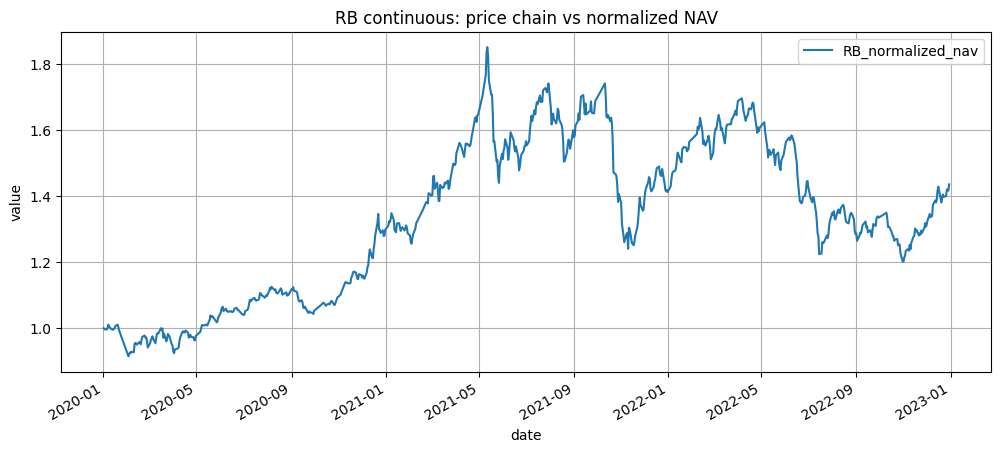

In [14]:
ax = pd.DataFrame({
    #"RB_price_chain": cs_rb_price.prices,
    "RB_normalized_nav": cs_rb_norm.prices,
}).plot(figsize=(12, 5), grid=True, title="RB continuous: price chain vs normalized NAV")
ax.set_xlabel("date")
ax.set_ylabel("value")


## 5. 海外数据：格式适配验证

海外数据的核心验证点在于：
- `KlineSchema.overseas()` 是否能适配 `daily_{BaseTicker}.parquet`
- `ContractSchema.overseas()` 是否能把 `RawContractID` 规范化到 `{BaseTicker}_{RawContractID}`
- `InstrumentSchema.overseas_from_contracts()` 是否能提供最小可用的 instrument 主数据


In [15]:
inst_es = overseas_loader.load_instrument("ES")
inst_es


Instrument(symbol='ES', name='MINI S&P 500 INDEX', exchange='', currency='USD', lot_size=1.0, tick_size=1.0, margin_rate=0.1)

In [16]:
cs_es = overseas_loader.load_continuous(
    "ES",
    start="2000-01-01",
    end="2005-01-01",
    adjust="nav",
    nav_output="normalized",
    stability_days=3,
)
cs_es


ContinuousSeries(symbol='ES', rows=1257, range=[2000-01-03 ~ 2004-12-31])

In [17]:
pd.DataFrame({
    "ES_normalized_nav": cs_es.prices.head(10),
})


,ES_normalized_nav
2000-01-03,1.000000
2000-01-04,0.962503
2000-01-05,0.963662
2000-01-06,0.957186
2000-01-07,0.995705
2000-01-10,1.005590
2000-01-11,0.991478
2000-01-12,0.983093
2000-01-13,0.994341
2000-01-14,1.007636


In [18]:
len(cs_es.schedule.events), cs_es.schedule.to_series().head()


(21,
 2000-01-03     ES_32581
 2000-03-17    ES_212857
 2000-06-19    ES_132235
 2000-09-18     ES_49912
 2000-12-18    ES_163223
 Name: ES, dtype: str)

## 6. 研究结论与后续观察点

当前 notebook 验证结论：
- `data` 层已经能在真实市场数据上稳定加载国内与海外数据
- `BarSeries`、`Contract`、`TradingCalendar`、`Instrument`、`ContinuousSeries` 主路径可用
- `load_continuous()` 已支持价格链和标准化净值链双模式
- 第一版 `instrument_source` 已可用，但 `tick_size` / `margin_rate` 仍可能落默认值

建议后续继续研究：
1. 将国内/海外 instrument 主数据预处理为独立标准文件
2. 为预构建 continuous 补充更完整的 companion schedule 文件规范
3. 在 notebook 之外把这些检查沉淀为更细粒度的 benchmark / regression 脚本
